<a href="https://colab.research.google.com/github/Sharath0Kumar/aiml_lab/blob/main/AML_LAB7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv('placement.csv')

df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


In [ ]:
X = df[['cgpa']]
y = df['package']

print("X:")
print(X.head())

print("\ny:")
print(y.head())

X:
   cgpa
0  6.89
1  5.12
2  7.82
3  7.42
4  6.94

y:
0    3.26
1    1.98
2    3.25
3    3.67
4    3.57
Name: package, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (160, 1)
Testing data: (40, 1)


In [ ]:
print("Training Data:")
print(X_train.head())

print("\nTraining Target:")
print(y_train.head())

print("\nTesting Data:")
print(X_test.head())

print("\nTesting Target:")
print(y_test.head())

Training Data:
     cgpa
79   7.18
197  7.21
38   8.62
24   6.53
122  5.12

Training Target:
79     3.00
197    3.24
38     4.36
24     2.71
122    2.01
Name: package, dtype: float64

Testing Data:
     cgpa
95   6.63
15   7.25
30   7.36
158  5.95
128  7.93

Testing Target:
95     2.79
15     3.23
30     3.26
158    3.04
128    3.34
Name: package, dtype: float64


**Train Linear Regression**

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [ ]:
print("Coefficient (slope):", model.coef_[0])
print("Intercept:", model.intercept_)

print("\nRegression Equation:")
print(f"Package = {model.coef_[0]:.4f} × CGPA + {model.intercept_:.4f}")

Coefficient (slope): 0.5742564727019197
Intercept: -1.0270069374542108

Regression Equation:
Package = 0.5743 × CGPA + -1.0270


In [ ]:
y_pred = model.predict(X_test)

print("Predicted Packages:")
print(y_pred[:10])

Predicted Packages:
[2.78031348 3.13635249 3.1995207  2.38981908 3.52684689 3.76803461
 3.16506531 2.54486832 3.17655044 3.4923915 ]


In [ ]:
comparison = pd.DataFrame({
    'Actual Package': y_test.values,
    'Predicted Package': y_pred
})

print(comparison.head(10))

   Actual Package  Predicted Package
0            2.79           2.780313
1            3.23           3.136352
2            3.26           3.199521
3            3.04           2.389819
4            3.34           3.526847
5            4.21           3.768035
6            2.94           3.165065
7            2.87           2.544868
8            2.99           3.176550
9            3.58           3.492392


In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)

Mean Squared Error (MSE): 0.08417638361329656
Root Mean Squared Error (RMSE): 0.2901316659954521


In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7730984312051673


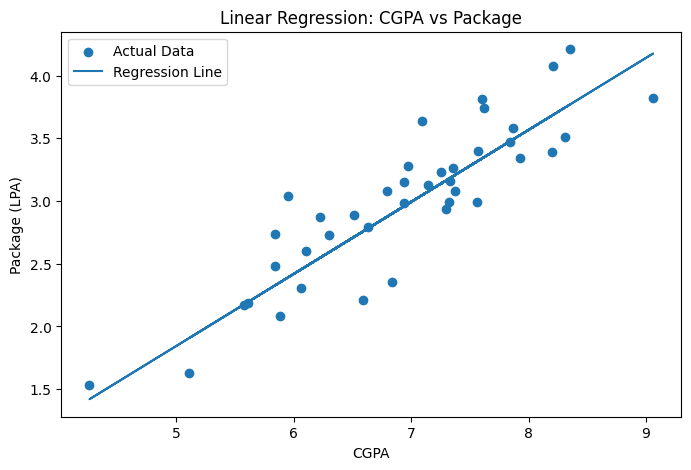

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual Data")

plt.plot(X_test, y_pred, label="Regression Line")

plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("Linear Regression: CGPA vs Package")

plt.legend()
plt.show()

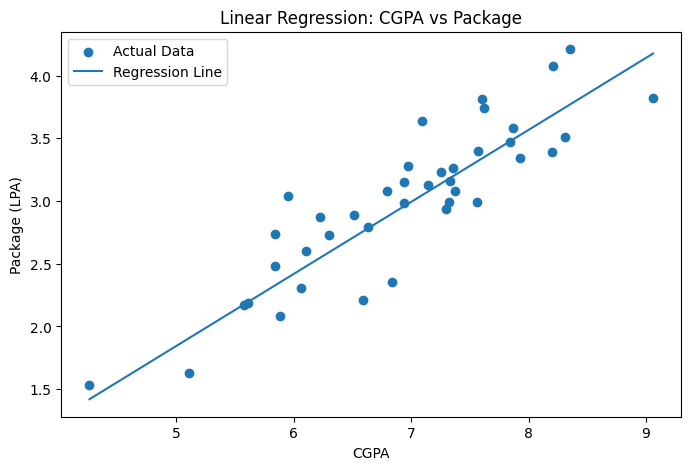

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(X_test, y_test, label="Actual Data")

sorted_indices = X_test['cgpa'].argsort()

plt.plot(
    X_test['cgpa'].iloc[sorted_indices],
    y_pred[sorted_indices],
    label="Regression Line"
)

plt.xlabel("CGPA")
plt.ylabel("Package (LPA)")
plt.title("Linear Regression: CGPA vs Package")

plt.legend()
plt.show()